## Expectation-Maximization and Variational EM algorithms.
## Simulation exercises for a Mixture-of-Gaussians model. 

### Introduction
This Notebook performs simulations where the Expectation-Maximization (EM) algorithm and the Amortized Variational EM algorithm are used to fit a Mixture-of-Gaussians model to data generated from the same model. Two initializations of the algorithms are considered: random and k-means.

**Goals**
- Assess the correctness of the implementation in the package AAIMF created for this project.
- Check the overall performance of the Expectation-Maximization algorithm (EM) and the Amortized Variational EM algorithm (AVEM).
- Compare the structure inferred by the neural network for the log-odds with the exact theoretical form.

### Load workspace saved in a previous session
At the end of the Notebook, the workspace is saved to an .RData file. It can be loaded. 

This avoids having to run the entire simulation. The execution of the simulation may be skipped. The results of the simulation are stored in the object `results_list`. See the Section of results below.

In [1]:
#load(file = "/home/jupyter-aai26_javier.lopez-7483b/MoG-VI/sim-em-diag-cov.RData")

### Load AAIMF R package, auxiliary libraries and functions

In [1]:
pkg_lib <- "/home/jupyter-aai26_javier.lopez-7483b/.conda/envs/r-env/lib/R/library"
install.packages("../../AAIMF_0.1.8.tar.gz", lib = pkg_lib, repos = NULL, type = "source", verbose=FALSE)
#find.package("AAIMF")
packageVersion("AAIMF")

[1] ‘0.1.8’

In [3]:
library(AAIMF)
library(future)
library(future.apply)
library(progressr)

# auxiliary functions

source("../fn_auxiliary.R")
source("./fn-img-tools.R")

collect_results <- function(fit, tt, dgp_vec_pars, dgp_states)
{
  z1 <- max.col(fit$model$rprobs)
  list(time = unname(tt["elapsed"]),
       point_bias = unlist(fit$model$pars) - dgp_vec_pars,
       accuracy = mean(z1 == dgp_states),
       tab = table(true = dgp_states, estimated = z1))
}

summarize <- function(res_list, item_name, prefix = TRUE, ndecs = 3)
{
  tab <- apply(do.call("rbind", lapply(res_list, function(x) x[[item_name]])), 2, summary)
  if (is.list(tab))
    do.call("rbind", tab)
  if (prefix)
    colnames(tab) <- paste(strsplit(item_name, "_")[[1]][1], colnames(tab), sep ="_")
  round(tab, ndecs)
}

### Choose simulation parameters

In [3]:
# number of simulation iterations and seed

niter <- 100 #10000
seed <- 123

# model

model_family <- 'mog_diagonal_cov' # 'mog_full_cov'

# width of the neural-network

nn_width <- 4

# parameters of the data generating process

dgp <- list(
  N = 75, # sample size
  pis = c(0.35, 0.65), # mixing probabilities
  mus = rbind(c(-2, -1), c(2, 1)), # component's means
  Sigmas = list(diag(c(0.4, 0.8)), diag(c(0.8, 0.6)))) # component's covariance matrix

# number of cores used in the parallel execution

available_workers <- parallel::detectCores()
nworkers <- 50 #parallel::detectCores() - 1
cat(paste(sprintf("Using %d cores out of %d available cores.", nworkers, available_workers)))

Using 50 cores out of 256 available cores.

#### Further auxiliary elements and sanity checks

In [4]:
tmp <- dgp_sanity_checks(dgp, model_family)

dgp$Lambdas <- tmp$Lambdas
dgp_pars_nms <- tmp$dgp_pars_nms
dgp_vec_pars <- tmp$dgp_vec_pars
dgp_struct <- tmp$dgp_struct

rm(tmp)

OK DGP definition.
OK The order of the parameters in the DGP specification and in the model match each other.


### Computations for one iteration of the simulation

In [5]:
one_iteration <- function(i)
{
  #set.seed(123)

  # Generate data

  dgp_data <- mog_sim(N = dgp$N, pis = dgp$pis,
    mus = dgp$mus, Sigmas = dgp$Sigmas)
    #seed = 123 # handled by clusterSetRNGStream()

  ## ============ ============ ============ ============ ============ ============
  ## EM (loglik)
  ## ============ ============ ============ ============ ============ ============
    
  model1 <- make_model(model_family, dgp_data$X, dgp_data$K)

  # ------------ ------------ ------------ ------------ ------------ ------------
  # EM (loglik) random initialization
  # ------------ ------------ ------------ ------------ ------------ ------------

  #model1_ir <- em_init(model1, method="random") # seed = NULL
  #fit1__ir_v0 <- em_run(model1_ir, maxiter = 500, tol = 1e-8,
  #  verbose = FALSE, debug = FALSE,
  #  do_sort = list(by_column = 1L, decreasing = FALSE))

  t1_ir <- system.time({
    model1_ir <- em_init(model1, method = "random") # seed = NULL
      
    fit1_ir <-  avem_run(model1_ir,
      target = "loglik",
      maxiter = 500, tol = 1e-8,
      verbose = FALSE, debug = FALSE)
  })

  info1_ir <- collect_results(fit1_ir, t1_ir, dgp_vec_pars, dgp_data$states)

  # ------------ ------------ ------------ ------------
  # EM (loglik) k-means initialization
  # ------------ ------------ ------------ ------------

  t1_ik <- system.time({
    model1_ik <- em_init(model1, method = "kmeans")
      
    fit1_ik <-  avem_run(model1_ik,
      target = "loglik",
      maxiter = 500, tol = 1e-8,
      verbose = FALSE, debug = FALSE)
  })

  info1_ik <- collect_results(fit1_ik, t1_ik, dgp_vec_pars, dgp_data$states)

  ## ============ ============ ============ ============ ============ ============
  ## Amortized Variational EM (ELBO, neural-network inference mapping)
  ## ============ ============ ============ ============ ============ ============

  # NOTE "Nelder-Mead" faster than "BFGS", but worse results in this simulation.

  config_am <- list(features_fn = function(X) cbind(1, X, X^2),
    fn = "forward_network", args_fn = list(), nn_width=4)

  model2 <- make_model(model_family, dgp_data$X, dgp_data$K,
    amortization = config_am)

  # ------------ ------------ ------------ ------------
  # AVEM random initialization
  # ------------ ------------ ------------ ------------

  t2_ir <- system.time({
    model2_ir <- em_init(model2, method = "random") # seed = NULL
      
    fit2_ir <- avem_run(model2_ir,
      target = "elbo",
      maxiter = 500, tol = 1e-8,
      optim_args = list(method = "BFGS", hessian = FALSE),
      verbose = FALSE, debug = FALSE)
  })

  info2_ir <- collect_results(fit2_ir, t2_ir, dgp_vec_pars, dgp_data$states)

  # ------------ ------------ ------------ ------------ ------------ ------------
  # AVEM k-means initialization
  #
  # The k-means initialization starts in turn from a random initialization. 
  # The model is fitter four times with for different random initializations for 
  # the k-means initialization. 
  # The first fit and the fit where the ELBO is the highest are recorded. 
  # This allows assessing the effect of the preliminary random initialization 
  # ------------ ------------ ------------ ------------ ------------ ------------

  fit2_ik_lst <- replicate(4, list())
  t2_ik_lst <- replicate(4, list())
  elbo_ref_val <- -Inf

  for (i in seq_along(fit2_ik_lst))
  {
    t2_ik_lst[[i]] <- system.time({
      model2_ik <- em_init(model2, method = "kmeans",
        init_args = list(nstart = 20, prob = 0.95))

      fit2_ik_lst[[i]] <- avem_run(model2_ik,
        target = "elbo",
        maxiter = 500, tol = 1e-8,
        optim_args = list(method = "BFGS", hessian = FALSE),
        verbose = FALSE, debug = FALSE)
    })

    current_elbo <- tail(fit2_ik_lst[[i]]$target_path, 1)

    if (current_elbo > elbo_ref_val)
    {
        id_max_elbo <- i
        elbo_ref_val <- current_elbo
    }
  }

  fit2_ik_first <- fit2_ik_lst[[1]]
  fit2_ik_best <- fit2_ik_lst[[id_max_elbo]]
  #t2_ik_lst[[id_max_elbo]]
  t2_ik_total <- colSums(do.call("rbind", t2_ik_lst))

  info2_ik_first <- collect_results(fit2_ik_first, t2_ik_lst[[1]], dgp_vec_pars, dgp_data$states)
  info2_ik_best <- collect_results(fit2_ik_best, t2_ik_total, dgp_vec_pars, dgp_data$states)
    
  # Output

  list(dgp_states = dgp_data$states,
    fit1_ir = fit1_ir, fit1_ik = fit1_ik, fit2_ir = fit2_ir, fit2_ik_first = fit2_ik_first, fit2_ik_best = fit2_ik_best,
    runtime = c(m1_ir = info1_ir$time, m1_ik = info1_ik$time, m2_ir = info2_ir$time, m2_ik_first = info2_ik_first$time, m2_ik_best = info2_ik_best$time),
    niter = c(m1_ir = fit1_ir$niter, m1_ik = fit1_ik$niter, m2_ir = fit2_ir$niter, m2_ik_first = fit2_ik_first$niter, m2_ik_best = fit2_ik_best$niter),
    p1_ir = unlist(fit1_ir$model$pars, TRUE, TRUE), p1_ik = unlist(fit1_ik$model$pars, TRUE, TRUE), 
    p2_ir = unlist(fit2_ir$model$pars, TRUE, TRUE),
    p2_ik_first = unlist(fit2_ik_first$model$pars, TRUE, TRUE), p2_ik_best = unlist(fit2_ik_best$model$pars, TRUE, TRUE),
    b1_ir = info1_ir$point_bias, b1_ik = info1_ik$point_bias, b2_ir = info2_ir$point_bias,
    b2_ik_first = info2_ik_first$point_bias, b2_ik_best = info2_ik_best$point_bias,
    accuracy = c(m1_ir = info1_ir$accuracy, m1_ik = info1_ik$accuracy, m2_ir = info2_ir$accuracy, m2_ik_first = info2_ik_first$accuracy, m2_ik_best = info2_ik_best$accuracy))
}

#### Run test example

In [6]:
test_run <- one_iteration(1)

In [8]:
#print(test_run)

### Parallel execution of the simulation

In [9]:
future::plan(multicore, workers = nworkers)

#handlers(global = TRUE)
handlers("txtprogressbar")

res_list <- with_progress({
  p <- progressor(along = seq_len(niter))

  future_lapply(
    X = seq_len(niter),
    FUN = function(i) {
      res = one_iteration(i)
      p() # update progress
      res
    },
    future.seed = seed
  )
})

future::plan(future::sequential) # back to sequential processing

### Results. Overview

In [10]:
names(res_list[[1]])

[1] "dgp_states"    "fit1_ir"       "fit1_ik"       "fit2_ir"      
 [5] "fit2_ik_first" "fit2_ik_best"  "runtime"       "niter"        
 [9] "p1_ir"         "p1_ik"         "p2_ir"         "p2_ik_first"  
[13] "p2_ik_best"    "b1_ir"         "b1_ik"         "b2_ir"        
[17] "b2_ik_first"   "b2_ik_best"    "accuracy"

#### Run time

**EM is substantially faster than AVEM** in this experiment. Its median run time is 0.010 seconds with random initialization and 0.006 seconds with k-means initialization. AVEM requires a median of 12.066 seconds with random initialization and 6.835 seconds for the first k-means initialization. 

Selecting the highest ELBO among four k-means-pretrained neural-network starts raises the median total time to 27.406 seconds because the times of all four fits are included. **This large difference is expected**: the EM E-step is analytical, whereas each AVEM iteration performs a numerical BFGS optimization over the neural-network parameters.

In [11]:
t(summarize(res_list, "runtime"))

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.
runtime_m1_ir,0.007,0.009,0.010,0.011,0.012,0.047
runtime_m1_ik,0.003,0.005,0.006,0.006,0.007,0.016
runtime_m2_ir,0.044,9.028,12.066,11.306,14.695,23.154
runtime_m2_ik_first,0.186,3.405,6.835,6.623,9.428,15.919
runtime_m2_ik_best,7.375,21.714,27.406,27.024,31.492,55.043


#### Number of iterations

**K-means initialization reduces the number of iterations required for convergence.** For EM, the median decreases from 13 iterations under random initialization to 6 under k-means initialization. For AVEM decreases from 11 to 4 for the first k-means initialized fit. The selected best-of-four AVEM fit has a median of 6 iterations.

These counts should not be interpreted as measures of computational cost (for that see the previous subsection on run times), since an AVEM iteration contains a comparatively expensive neural-network optimization. 

These counts show that the algorithms converge in a relatively low number of iterations in this model. This provides evidence on the overall correctness of the implementation.

In [12]:
t(summarize(res_list, "niter"))

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.
niter_m1_ir,8,11,13,14.04,15,66
niter_m1_ik,3,4,6,6.58,8,22
niter_m2_ir,1,8,11,11.37,14,32
niter_m2_ik_first,1,3,4,4.90,6,22
niter_m2_ik_best,2,5,6,6.75,8,22


#### Parameter estimates. Summary statistics

Both EM initializations recover the mixing probabilities and component means accurately. The average estimates under k-means initialization are (0.351,0.649) for the mixing probabilities and (-1.993,1.980) and (-1.002,0.990) for the two coordinates of the component means, close to the generating values (0.35,0.65), (-2,2), and (-1,1) respectively. Random initialization gives nearly identical average results, although it produces a few more extreme estimates; **k-means initialization is therefore somewhat more stable in addition to converging faster**.

The EM estimates of the **precision parameters tend to exceed the true generating values** slightly. For example, with k-means initialization their means are approximately (2.772,1.442,1.333,1.771), compared with the true values (2.5,1.25,1.25,1.667). By itself, this does not suggest an implementation problem. **It is compatible with maximum likelihood estimation  of precisions with a sample containing only 75 observations divided between two components.** 

**AVEM with a single neural-network initialization** usually gives sensible estimates, but **occasional inferior solutions** noticeably affect its means, tails and minima. This is especially visible in component means moving toward the center and in some unusually small precision estimates. **A single k-means pretrained network does not eliminate this behaviour and is not clearly better here than random initialization**. 

In contrast, **selecting the highest ELBO among four neural-network starts produces summaries almost identical to those of k-means-initialized EM**. For example, its mean estimates of the component means are approximately (-1.993,1.980) and (-1.002,0.990). Thus, the main difference arises from numerical optimization and initialization rather than from a systematic discrepancy between the EM and AVEM solutions.

##### **EM random initialization**

In [13]:
rbind(
  summarize(res_list, "p1_ir"),
  "DGP" = round(dgp_vec_pars, 3))

,p1_pis1,p1_pis2,p1_mus1,p1_mus2,p1_mus3,p1_mus4,p1_Lambdas1,p1_Lambdas2,p1_Lambdas3,p1_Lambdas4
Min.,0.227,0.516,-2.281,1.680,-1.352,0.533,0.471,0.566,0.744,1.087
1st Qu.,0.306,0.613,-2.083,1.890,-1.103,0.912,2.230,1.082,1.139,1.525
Median,0.350,0.650,-1.995,1.969,-1.021,1.006,2.637,1.389,1.310,1.702
Mean,0.352,0.648,-1.985,1.982,-1.000,0.992,2.747,1.443,1.336,1.790
3rd Qu.,0.387,0.694,-1.900,2.084,-0.894,1.067,3.152,1.660,1.538,2.003
Max.,0.484,0.773,-1.116,2.270,-0.501,1.255,6.421,2.967,2.072,3.888
DGP,0.350,0.650,-2.000,2.000,-1.000,1.000,2.500,1.250,1.250,1.667


##### **EM k-means initialization**

In [14]:
rbind(
  summarize(res_list, "p1_ik"),
  "DGP" = round(dgp_vec_pars, 3))

,p1_pis1,p1_pis2,p1_mus1,p1_mus2,p1_mus3,p1_mus4,p1_Lambdas1,p1_Lambdas2,p1_Lambdas3,p1_Lambdas4
Min.,0.227,0.516,-2.281,1.680,-1.352,0.533,1.141,0.566,0.744,1.087
1st Qu.,0.306,0.613,-2.083,1.889,-1.103,0.912,2.249,1.082,1.136,1.525
Median,0.347,0.653,-1.995,1.969,-1.021,1.000,2.658,1.389,1.299,1.702
Mean,0.351,0.649,-1.993,1.980,-1.002,0.990,2.772,1.442,1.333,1.771
3rd Qu.,0.387,0.694,-1.900,2.084,-0.894,1.066,3.152,1.660,1.538,1.976
Max.,0.484,0.773,-1.640,2.270,-0.501,1.255,6.421,2.967,2.072,2.968
DGP,0.350,0.650,-2.000,2.000,-1.000,1.000,2.500,1.250,1.250,1.667


##### **Variational EM random initialization**

In [15]:
rbind(
  summarize(res_list, "p2_ir"),
  "DGP" = round(dgp_vec_pars, 3))

,p2_pis1,p2_pis2,p2_mus1,p2_mus2,p2_mus3,p2_mus4,p2_Lambdas1,p2_Lambdas2,p2_Lambdas3,p2_Lambdas4
Min.,0.240,0.497,-2.273,0.112,-1.352,0.152,0.220,0.556,0.220,0.556
1st Qu.,0.307,0.600,-2.064,1.880,-1.085,0.881,2.107,1.005,1.114,1.480
Median,0.356,0.644,-1.984,1.968,-0.989,0.987,2.467,1.297,1.268,1.685
Mean,0.361,0.639,-1.786,1.872,-0.897,0.936,2.495,1.374,1.254,1.695
3rd Qu.,0.400,0.693,-1.856,2.070,-0.849,1.064,2.983,1.630,1.469,1.948
Max.,0.503,0.760,0.853,2.270,0.438,1.255,6.421,2.967,2.072,2.968
DGP,0.350,0.650,-2.000,2.000,-1.000,1.000,2.500,1.250,1.250,1.667


##### **Variational EM k-means initialization (first trial)**

In [16]:
rbind(
  summarize(res_list, "p2_ik_first"),
  "DGP" = round(dgp_vec_pars, 3))

,p2_pis1,p2_pis2,p2_mus1,p2_mus2,p2_mus3,p2_mus4,p2_Lambdas1,p2_Lambdas2,p2_Lambdas3,p2_Lambdas4
Min.,0.227,0.314,-2.281,0.323,-1.352,0.152,0.221,0.563,0.221,0.563
1st Qu.,0.307,0.599,-2.082,1.863,-1.095,0.881,2.089,1.044,1.096,1.467
Median,0.359,0.641,-1.992,1.958,-1.004,0.987,2.543,1.312,1.238,1.678
Mean,0.374,0.626,-1.755,1.864,-0.886,0.934,2.511,1.391,1.225,1.681
3rd Qu.,0.401,0.693,-1.855,2.073,-0.845,1.060,2.991,1.659,1.480,1.976
Max.,0.686,0.773,0.951,2.253,0.485,1.255,6.421,2.967,2.092,2.968
DGP,0.350,0.650,-2.000,2.000,-1.000,1.000,2.500,1.250,1.250,1.667


##### **Variational EM k-means initialization (best out of 4 trials)**

In [17]:
rbind(
  summarize(res_list, "p2_ik_best"),
  "DGP" = round(dgp_vec_pars, 3))

,p2_pis1,p2_pis2,p2_mus1,p2_mus2,p2_mus3,p2_mus4,p2_Lambdas1,p2_Lambdas2,p2_Lambdas3,p2_Lambdas4
Min.,0.227,0.516,-2.281,1.680,-1.352,0.533,1.138,0.566,0.747,1.087
1st Qu.,0.306,0.613,-2.083,1.889,-1.103,0.912,2.249,1.082,1.136,1.526
Median,0.347,0.653,-1.995,1.969,-1.021,1.000,2.658,1.389,1.299,1.702
Mean,0.351,0.649,-1.993,1.980,-1.002,0.990,2.773,1.442,1.334,1.771
3rd Qu.,0.387,0.694,-1.900,2.084,-0.894,1.066,3.152,1.660,1.538,1.976
Max.,0.484,0.773,-1.640,2.270,-0.501,1.255,6.421,2.967,2.072,2.968
DGP,0.350,0.650,-2.000,2.000,-1.000,1.000,2.500,1.250,1.250,1.667


In [18]:
# Parameter estimates. Bias with respect true parameters.
#summarize(res_list, "b1_ir") # EM random initialization
#summarize(res_list, "b1_ik") # EM k-means initialization
#summarize(res_list, "b2_ik_first") # Variational EM k-means initialization (first trial)
#summarize(res_list, "b2_ik_best") # Variational EM k-means initialization (best out of 4 trials)

#### Accuracy

**Classification accuracy is extremely high because the two true generating components are strongly separated:** All methods has median accuracy equal to 1. EM achieves mean accuracies of 0.997 and 0.998 under random and k-means initialization, respectively. Single-start AVEM remains accurate in most replications but has means of 0.957 and 0.944, with minima of 0.293, revealing occasional poor optima. 

**Selecting the best ELBO among four starts raises mean accuracy to 0.998 and its minimum to 0.973, matching thereby k-means initialized EM in this simulation.** These results demonstrate the benefit of multiple neural-network starts, although due to the easy separation of the components this  should not be generalized to more difficult classification settings.

In [19]:
t(summarize(res_list, "accuracy"))

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.
accuracy_m1_ir,0.880,1.000,1,0.997,1,1
accuracy_m1_ik,0.973,1.000,1,0.998,1,1
accuracy_m2_ir,0.293,0.987,1,0.957,1,1
accuracy_m2_ik_first,0.293,0.987,1,0.944,1,1
accuracy_m2_ik_best,0.973,1.000,1,0.998,1,1


In [20]:
names(res_list[[1]]$p1_ir)
names(res_list[[1]])
grep("^p[[:digit:]]_.*", names(res_list[[1]]), value = TRUE)

[1] "pis1"     "pis2"     "mus1"     "mus2"     "mus3"     "mus4"    
 [7] "Lambdas1" "Lambdas2" "Lambdas3" "Lambdas4"

[1] "dgp_states"    "fit1_ir"       "fit1_ik"       "fit2_ir"      
 [5] "fit2_ik_first" "fit2_ik_best"  "runtime"       "niter"        
 [9] "p1_ir"         "p1_ik"         "p2_ir"         "p2_ik_first"  
[13] "p2_ik_best"    "b1_ir"         "b1_ik"         "b2_ir"        
[17] "b2_ik_first"   "b2_ik_best"    "accuracy"

[1] "p1_ir"       "p1_ik"       "p2_ir"       "p2_ik_first" "p2_ik_best"

### Results. Histograms of parameter estimates

**How to read the plots:**
- The panel displays histograms based on the estimates obtained in the simulation for each parameter and for each method.
- Parameters are displayed by rows: pis1, mus1, mus2, ...
- Methods are displayed by columns: EM random initialization and k-means initialization, Variational EM with random and k-means initialization.
- Vertical red lines stand for the true value used in the data generating process.
  
**Observations:**
- Overall, the implementation appears to be correct. **No anomalous or suspicious results are observed in this small simulation exercise.**
- The **first column in the panel** displays the histograms for each parameter (by rows: pis1, mus1, mus2, ...) obtained with standard **EM (optimizing log-Lik)** and using random initialization.
- The **second column** refers also to EM, but using **k-means initialization**. No major differences are observed. K-means initialization allows nonetheless reducing the number of iterations from 13 to 6 iterations on average.
- The **third column** displays histograms for the estimates obtained with **Amortized Variational EM (AVEM)** (optimizing ELBO) using **random initialization**. Although the overall performance is not bad, the presence of two modes or heavy tails suggest that in some of the data sets generated in the simulations parameter estimates were not satisfactory.
- The **fourth column** displays the histograms when **AVEM with k-means initialization** is used. No substantial improvement is observed with respect to random initialization (third column).
- This **fifth column** displays **AVEM with the best fit (highest ELBO) out of four** preliminary random initializatons used to start in turn k-means initialization. A relevant improvement with respect to the third and fourth columns is observed. The behaviour is in this case close to standard EM (first and second columns).
- **Computation time** is noticeably higher in AVEM when multiple neural-network initializations are used (the computation time of the 4 fits are added up, not just the time of the chosen fit). As we are interested in exploring the performance of each algorith, this is not critical. However, for future exercises or applications where AVEM could be applied to models where analytical expressions for the EM updates are not available, the implementation may need to be enhanced, for example with precompiled code.

**Scope of the exercise:**

- The simulation is intended as a **preliminary assessment of the implementation** of the EM and AVEM algorithms. Both algorithms have been **implemented from scratch** in the R package AAIMF (loaded at the beginning of this Notebook). After studying the models and algorithms, a unified interface `avem_run()` has been designed where mixture-of-Gaussians models can be fitted both by maximum likelihood and by means of amortized variational EM.
- The simulation is **small (100 iteration)** intended for overall illustration along the lines discussed above. Only two mixture components (K=2) are considered.
- **Accuracy** is very close to 1 in all the fits. The data-generating process defines components that strongly separated. Responsibilities turn out therefore to be close to zero or one. This makes the task of classification relatively easy (despite the number of observations is not large, 75 observations).
- If can be seen that for the selected model **the theoretical posterior log-odds are quadratic on the data**. As the amortizaton features contain the data and the squared data, the neural network is able to closely approximate the theoretical mapping.
- This exercise can be easily extended by choosing at the top of the Notebook a larger number of iterations and changing the parameters of the data-generating process.

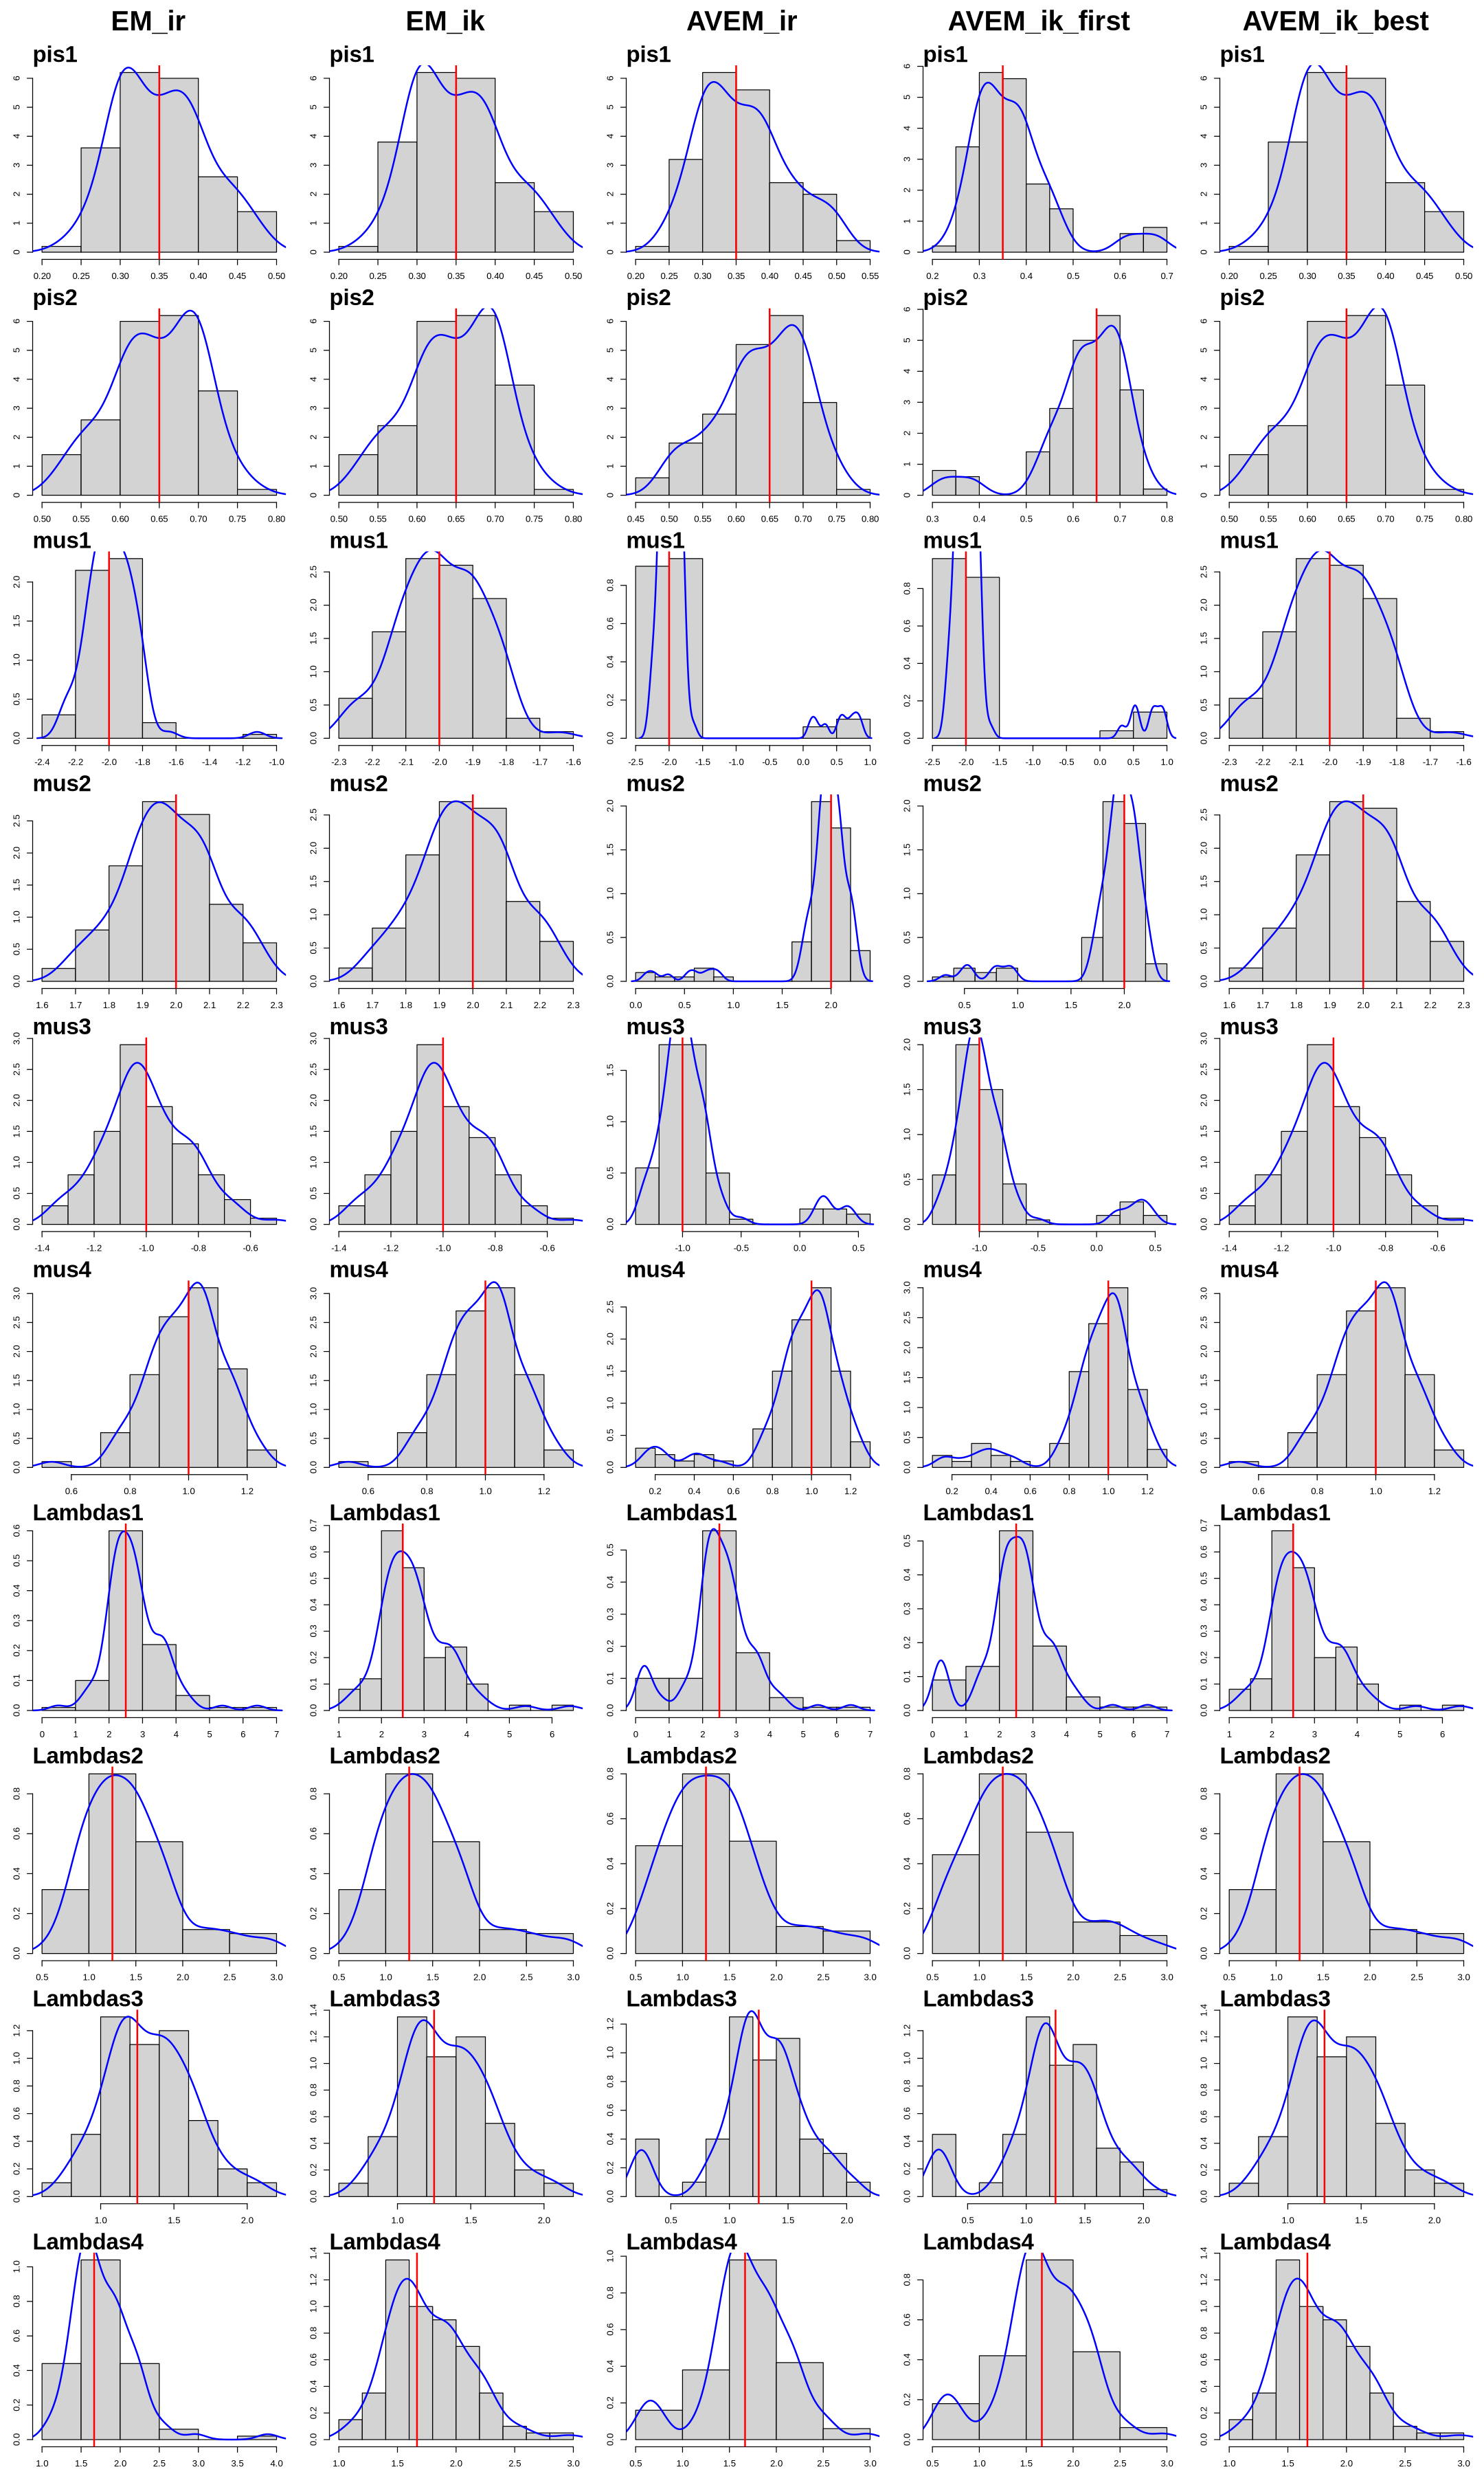

In [21]:
dgp_vec_pars <- unlist(dgp[dgp_pars_nms])

par_names <- names(res_list[[1]]$p1_ir)
#method_names <- c("p1_ir", "p1_ik", "p2_elbo_ir_first", "p2_elbo_ir_best")
method_names <- grep("^p[[:digit:]]_.*", names(res_list[[1]]), value = TRUE)
method_names_label <- sub("^p1", "EM", method_names)
method_names_label <- sub("^p2", "AVEM", method_names_label)

mfrow <- c(length(par_names), length(method_names))

options(repr.plot.width = 18, repr.plot.height = 30)

opar <- par(no.readonly = TRUE)
par(mfrow = mfrow, mar = c(2.5, 3, 2, 1), oma = c(0,0,4,0))

for (par_name in par_names)
{
  for (method_name in method_names)
  {
    v_vals <- unlist(lapply(res_list, function(x) x[[method_name]][par_name]))
    hist(v_vals, prob=TRUE, main = "")
    title(main = sprintf("%s", par_name), adj = 0, cex.main = 2.5, font.main = 2, line = 0.3)              
    lines(density(v_vals), col="blue", lwd=2)
    abline(v=dgp_vec_pars[par_name], col="red", lwd=2)
  }
}
mtext(method_names_label, side = 3, outer = TRUE, line = 1,
  at = (seq_along(method_names) - 0.5) / length(method_names), cex = 2, font = 2)
par(opar)

### Posterior log-odds. Exact vs amortized

For a two-component Gaussian mixture model with diagonal covariance matrix, the posterior log-odds are a quadratic function of the observations. This justifies the usage of the feature matrix
`cbind(1, X, X^2)` chosen above. 

For the full-covariance (and full precision) matrix model, we have:

\\[
p(\mathbf{x}_n\mid z_n=k) = (2\pi)^{-D/2} | \boldsymbol{\Lambda}_k|^{1/2}
\exp\left\{
-\frac{1}{2} (\mathbf{x}_n-\boldsymbol{\mu}_k)^{\mathsf T} \boldsymbol{\Lambda}_k (\mathbf{x}_n-\boldsymbol{\mu}_k)
\right\}.
\\]

Applying Bayes' rule we get:

\\[
\frac{p(z_n=2\mid\mathbf{x}_n)}{p(z_n=1\mid\mathbf{x}_n)} =
\frac{\pi_2p(\mathbf{x}_n\mid z_n=2)}{\pi_1p(\mathbf{x}_n\mid z_n=1)}.
\\]

Taking logarithms:

\\[
g(\mathbf{x}_n) = \log\frac{\pi_2}{\pi_1} +
\frac{1}{2}
\log\frac{|\boldsymbol{\Lambda}_2|} {|\boldsymbol{\Lambda}_1|} -
\frac{1}{2}
(\mathbf{x}_n-\boldsymbol{\mu}_2)^{\mathsf T} 
\boldsymbol{\Lambda}_2 (\mathbf{x}_n-\boldsymbol{\mu}_2) +
\frac{1}{2}
(\mathbf{x}_n-\boldsymbol{\mu}_1)^{\mathsf T}
\boldsymbol{\Lambda}_1 (\mathbf{x}_n-\boldsymbol{\mu}_1).
\\]

For diagonal precision matrices we have
\\( \boldsymbol{\Lambda}_k = \operatorname{diag} (\lambda_{k1},\ldots,\lambda_{kD}) \\).

Expanding the quadratic terms gives

\\[
g(\mathbf{x}) = c+\sum_{d=1}^{D}a_dx_d+\sum_{d=1}^{D}b_dx_d^2,
\\]

where

\\[
c = \log\frac{\pi_2}{\pi_1} +
\frac{1}{2} \sum_{d=1}^{D}\log\frac{\lambda_{2d}}{\lambda_{1d}} -
\frac{1}{2} \sum_{d=1}^{D} \left( \lambda_{2d}\mu_{2d}^2 - \lambda_{1d}\mu_{1d}^2 \right),
\\]

\\[
a_d =
\lambda_{2d}\mu_{2d} - \lambda_{1d}\mu_{1d},
\\]

\\[
b_d = \frac{1}{2} \left( \lambda_{1d}-\lambda_{2d} \right).
\\]

The exact responsibility for the second component is thus

\\[
\tau_2(\mathbf{x}) = \frac{\exp\{g(\mathbf{x})\}} {1+\exp\{g(\mathbf{x})\}} =
\operatorname{logistic}\{g(\mathbf{x})\}.
\\]

- The boundary between the two components satisfies \\( g(\mathbf{x}) = 0 \\), which is equivalent to \\( \tau_2(\mathbf{x})=1/2 \\).
- If \\( \boldsymbol{\Lambda}_1=\boldsymbol{\Lambda}_2 \\), then \\( \mathbf b = \mathbf 0 \\), and the decision boundary becomes a straight line.

The loop belows generate the plots for all iterations of the simulation. They are stored in the `plots` directory. Below a selection of these plots will be described.

In [7]:
for (i in seq_len(100))
{
  png(sprintf("./plots/EM_ik/fit_%d.png", i))

  fit <- res_list[[i]]$fit1_ik
  logodds <- fitted(fit)
  plot_fitted_log_odds(logodds, type="exact",
    main = sprintf("EM. Exact log-odds. Iteration %s.", i),
    pcols = c("orange", "seagreen")[res_list[[i]]$dgp_states])

  #Sys.sleep(2)
  dev.off()
}

In [4]:
type <- "best" # "first", #"best"
for (i in seq_len(100))
{
  png(sprintf("./plots/AVEM_ik_%s/fit_%d.png", type, i))
 
  #fit <- switch res_list[[i]]$fit2_ik_first
  fit <- res_list[[i]][[sprintf("fit2_ik_%s", type)]]
  logodds <- fitted(fit)
  plot_fitted_log_odds(logodds, type="difference",
    main = sprintf("Log-odds: Exact vs AVEM_i_kmeans_%s. Iteration %s.", type, i),
    pcols = c("orange", "seagreen")[res_list[[i]]$dgp_states])
    #pcols = c("#E69F00", "#009E73")[res_list[[i]]$dgp_states])

  #Sys.sleep(2)
  dev.off()
}

#### EM exact log-odds: representative regular examples

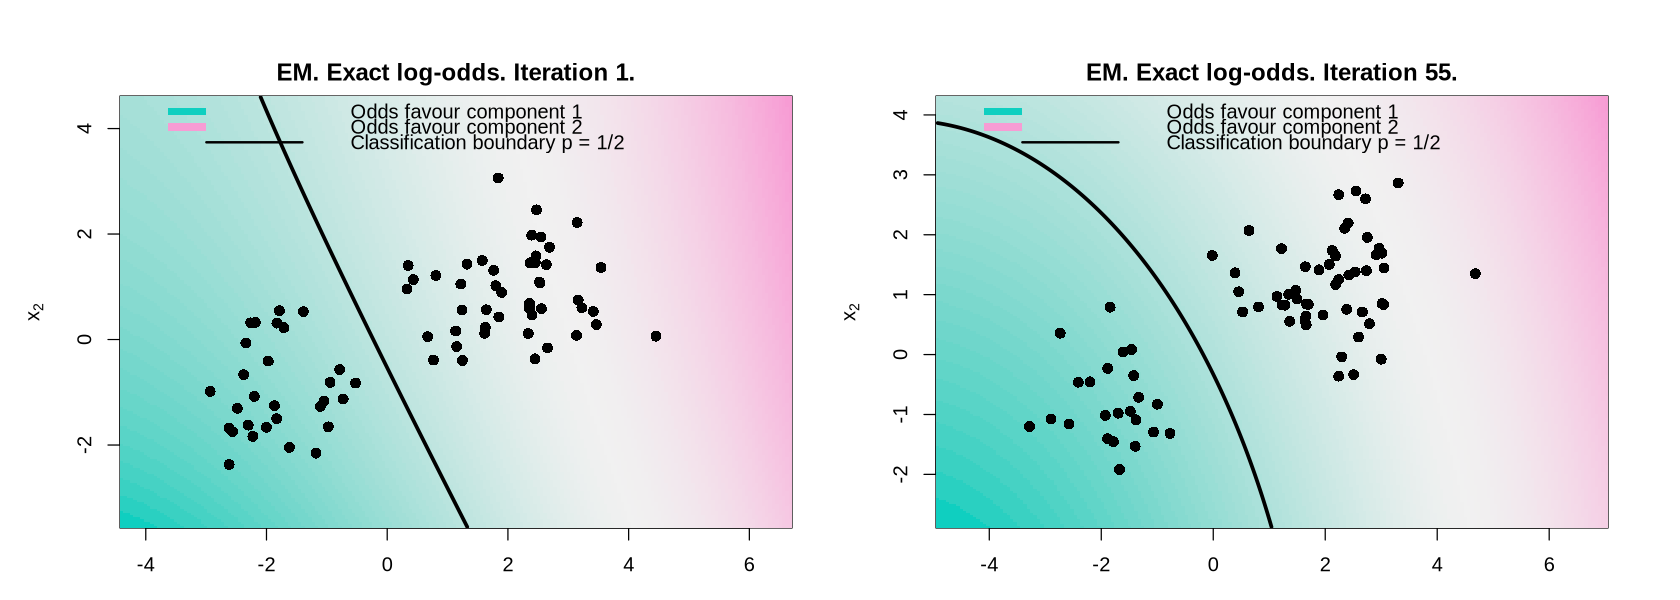

In [32]:
ids <- c(1, 55) #69

options(repr.plot.width = 14, repr.plot.height = 5)
opar <- par(no.readonly = TRUE)
par(mfrow = c(1,2), mar = c(2, 4, 2, 2), oma = c(1,1,2,1))
for (i in ids)
{
  logodds <- fitted( res_list[[i]]$fit1_ik )
  plot_fitted_log_odds(logodds, type="exact",
    main = sprintf("EM. Exact log-odds. Iteration %s.", i))
}
par(opar)

The plots displayed above illustrate the expected behavior of the exact posterior log-odds under the data generating process.

**`EM_ik/fit_1.png`:** The fitted boundary is nearly linear over the observed region and passes cleanly between the two data groups. Log-odds increasingly favor component 1 toward the lower-left region and component 2 toward the upper-right region. Although the theoretical boundary is quadratic, the quadratic contribution is modest over this part of the plane, so the curve is visually close to a straight line.

**`EM_ik/fit_55.png`:** This is another particularly clear fit. The two groups are well separated and the posterior boundary lies in the low-density region between them. Its slight curvature reflects the fact that the fitted diagonal precision matrices are not identical.

#### EM exact log-odds:  less usual examples

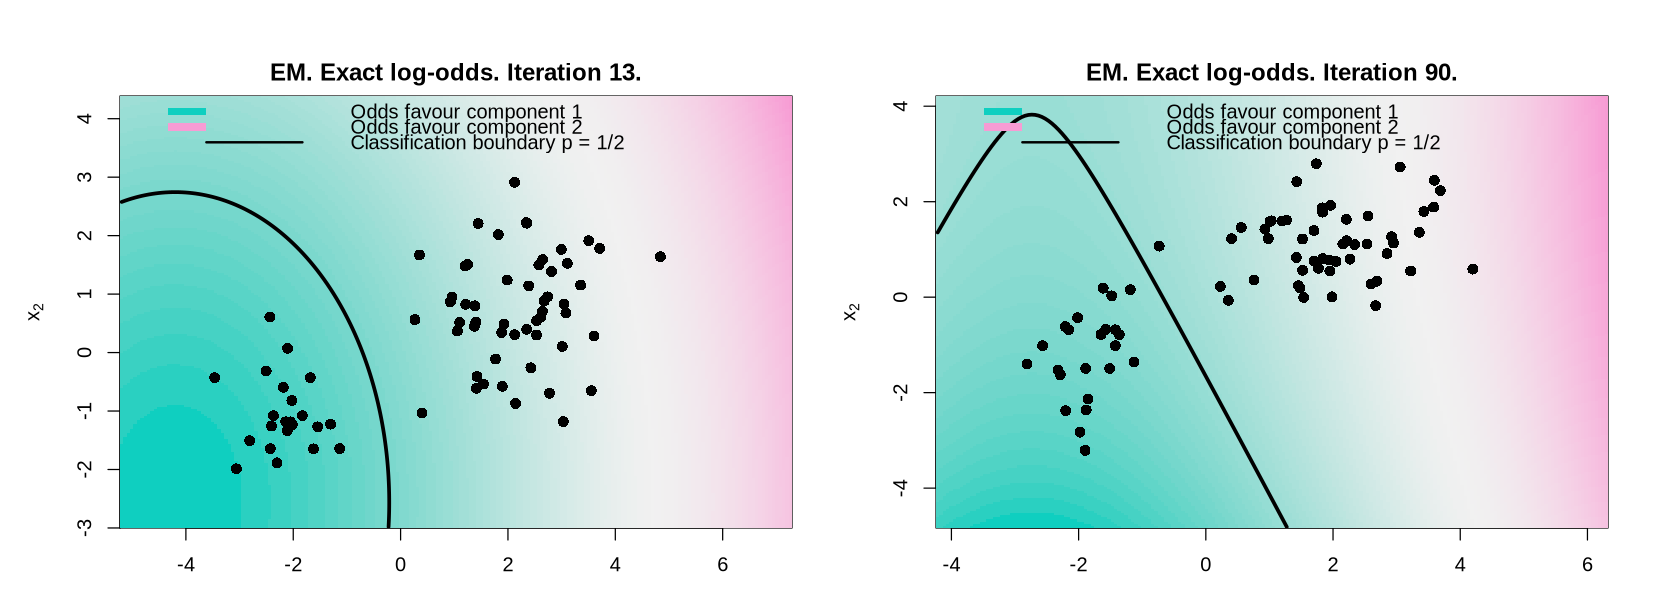

In [31]:
ids <- c(13, 90)

options(repr.plot.width = 14, repr.plot.height = 5)
opar <- par(no.readonly = TRUE)
par(mfrow = c(1,2), mar = c(2, 4, 2, 2), oma = c(1,1,2,1))
for (i in ids)
{
  logodds <- fitted( res_list[[i]]$fit1_ik )
  plot_fitted_log_odds(logodds, type="exact",
    main = sprintf("EM. Exact log-odds. Iteration %s.", i))
}
par(opar)

The plots above are somewhat more peculiar.

**`EM_ik/fit_13.png`:** The boundary has much stronger curvature and bends around the lower-left component. This appearance is less common than the nearly linear boundaries, but it is compatible with the analytical expression

\\[
g(\mathbf x) = c+\mathbf a^{\mathsf T}\mathbf x + \mathbf b^{\mathsf T} \mathbf (x_1^2,\ldots,x_D^2)^{\mathsf T}.
\\]

A relatively large fitted quadratic coefficient changes the geometry of the boundary while still separating the observations correctly.

**`EM_ik/fit_90.png`:** The boundary forms a pronounced arch near the top-left part of the plotting region. Nevertheless, the part of boundary closer to the sample continues along the empty region between the two groups and gives a sensible classification. The unusual curvature reflects sampling variability in the estimated component precisions rather than an apparent failure of EM.

These two examples are useful because they make the quadratic nature of the exact log-odds more visible than the nearly linear examples do.

#### Exact vs amortized log-odds: representative examples with close agreement

In the AVEM plots below, the red curve is the exact posterior boundary implied by its estimated mixture parameters, while the blue curve is the boundary produced by its fitted neural-network inference mapping. Thus, the background colouring represents the difference

\\[
g_{\boldsymbol{\eta}}(\mathbf x) - 
g_{\mathrm{exact}} \left( 
\mathbf x; \widehat{\boldsymbol{\theta}}_{\mathrm{AVEM}} \right).
\\]

**These plots assess how closely the amortized E-step reproduces the exact E-step conditional on the same fitted mixture parameters.**

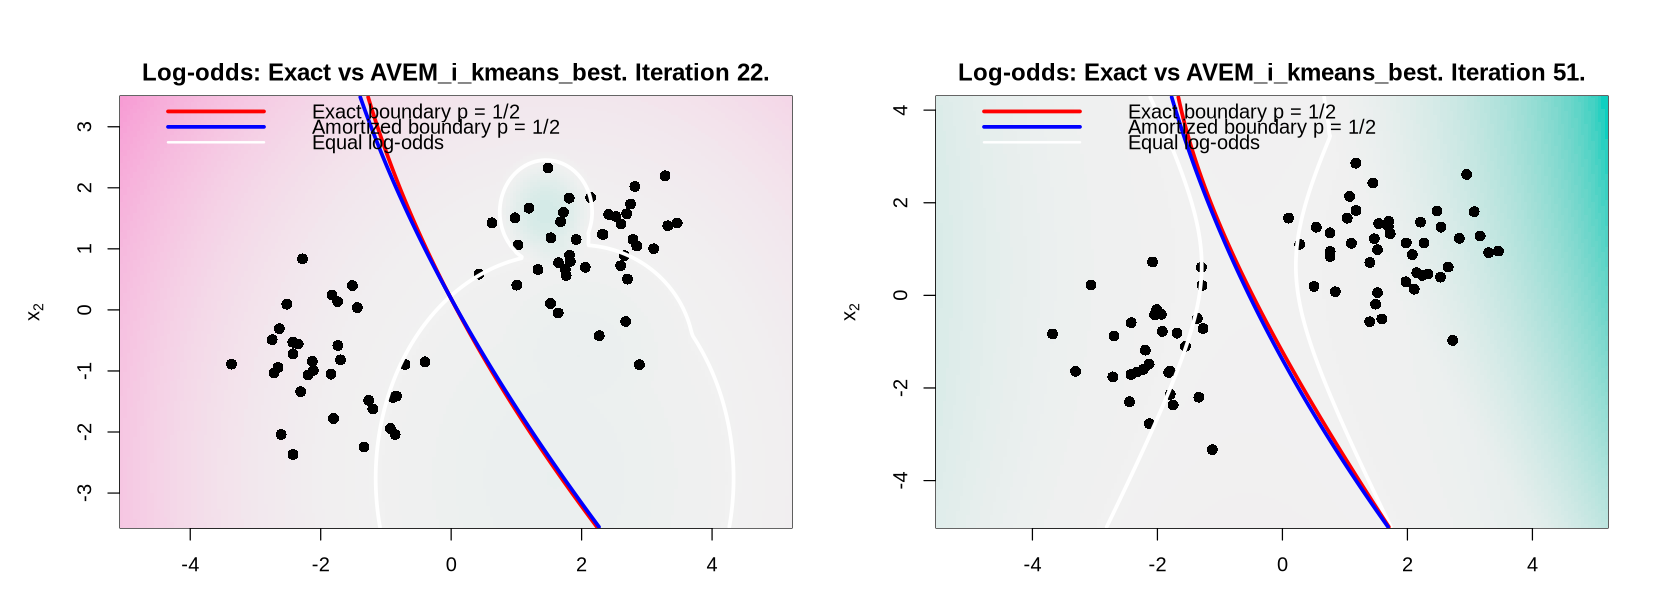

In [34]:
ids <- c(22, 51)

options(repr.plot.width = 14, repr.plot.height = 5)
opar <- par(no.readonly = TRUE)
par(mfrow = c(1,2), mar = c(2, 4, 2, 2), oma = c(1,1,2,1))
for (i in ids)
{
  logodds <- fitted( res_list[[i]][[sprintf("fit2_ik_%s", type)]] )
  plot_fitted_log_odds(logodds, type="difference",
    main = sprintf("Log-odds: Exact vs AVEM_i_kmeans_%s. Iteration %s.", type, i))
}
par(opar)

**`AVEM_ik_best/fit_22.png`:** The exact and amortized boundaries are almost superimposed throughout the region separating the observed groups. Therefore **the neural network has reproduced the most relevant part of the analytical posterior** mapping very accurately. The white equality contour elsewhere does not represent a classification boundary; it only identifies locations where the two numerical log-odds are equal.</p>

**`AVEM_ik_best/fit_51.png`:** The red and blue curves are again very close over essentially the entire displayed separating region. **Small deviations arise mostly away from the observations.** 

These plots illustrate the intended behavior of AVEM: with features containing \\(\mathbf x\\) and \\(\mathbf x^2\\), the neural network learns a mapping that closely approximates the quadratic exact log-odds.

#### Exact vs amortized log-odds: less usual examples

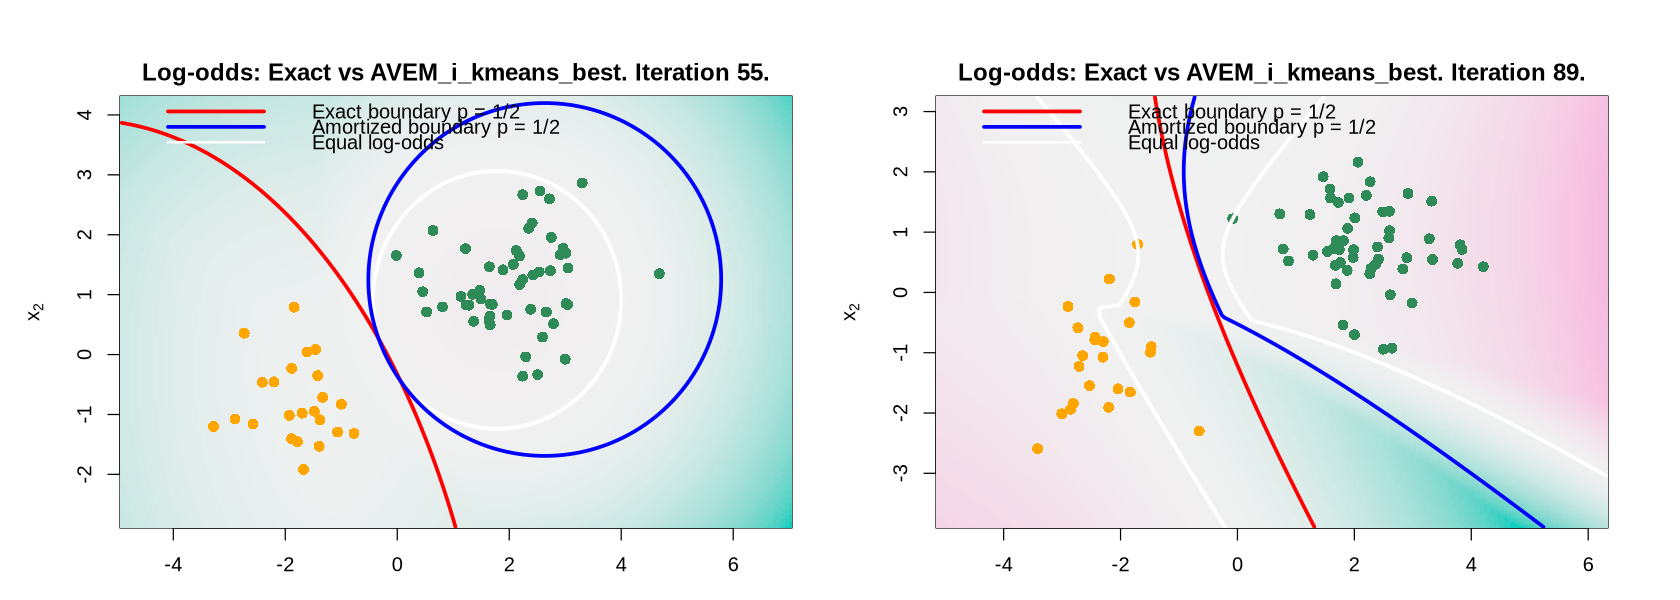

In [38]:
ids <- c(55, 89)

options(repr.plot.width = 14, repr.plot.height = 5)
opar <- par(no.readonly = TRUE)
par(mfrow = c(1,2), mar = c(2, 4, 2, 2), oma = c(1,1,2,1))
for (i in ids)
{
  logodds <- fitted( res_list[[i]][[sprintf("fit2_ik_%s", type)]] )
  plot_fitted_log_odds(logodds, type="difference",
    main = sprintf("Log-odds: Exact vs AVEM_i_kmeans_%s. Iteration %s.", type, i),
    pcols = c("orange", "seagreen")[res_list[[i]]$dgp_states])
}
par(opar)

**`AVEM_ik_best/fit_55.png`:** The amortized boundary is a closed oval surrounding the right-hand group, whereas the exact boundary is an open quadratic curve separating the two groups. This is a **substantial difference in the shape of the two mappings. Nevertheless, both boundaries classify the observed groups in essentially the same way**: the green observations lie inside the amortized oval and the orange observations lie outside it. 

This atypical shape suggests that **the neural network is more flexible than required to approximate the exact quadratic posterior mapping**. Because the ELBO constrains the network through its values at the observed data points, its behavior in less populated regions is only weakly determined. This may be regarded as an *unnecessary extrapolation of the amortized mapping* at points far from the data, rather than evidence that the fitted model fails to classify the observed data.

**`AVEM_ik_best/fit_89.png`:** Near the central region between the two groups, the exact and amortized boundaries remain reasonably close. Below the observations, however, the amortized boundary develops a visible change in direction and diverges from the smooth exact curve. 

This type of piecewise geometry is consistent with the ReLU architecture. Each ReLU applies the transformation \\( \operatorname{ReLU}(u)=\max(0,u) \\), which divides the input space into an active region and an inactive region. When an observation crosses a boundary at which a unit switches between these states, the analytical expression implemented by the network changes. **Combining several ReLUs produces therefore a mapping composed of different pieces, with changes in slope or curvature along their activation boundaries.** Since here the network received the features \\((1,\mathbf{x},\mathbf{x}^2)\\), the activation boundaries may produce piecewise curves joined by sharp corners or abrupt changes of direction in the fitted amortized classification boundary.

Observe also that the divergence occurs mainly in a region with little data, where the ELBO provides limited information. As a consequence, the fitted network may not reproduce the analytical mapping **globally**.

In [40]:
#33, 36, 37
#res_list[[36]]$fit1_ik$model$pars
#res_list[[36]]$fit2_ik_first$model$pars

### Conclusions

- This small simulation serves as a preliminary validation of the implementation.
- EM (optimizing log-likelihood) provides sensible parameter estimates, both with random and with k-means initialization.
- Variational EM (optimizes ELBO) is more sensitive to raw (randomly chosen) initial parameter values.
- When k-means initialization is used in Variational EM and the best of 4 preliminary random initializations are used (in short, with multiple neural-network starts), then the results are very close to standard EM.
- Multiple neural-network starts usually produce an AVEM inference map that closely approximates the exact posterior boundary in the empirically relevant region. Rather than a systematic implementation failure, the more unusual plots reveal global non-identification of the mapping away from the observations, as well as the flexibility of the ReLU network.

### Save current workspace / Load saved workspace

In order to avoid running the whole simulation to update the results displayed above, after running the simulation the workspace is stored in an .RData file. This workspace can be loaded to recover the results of the simulation. The cells in the sections of results can then be executed to display results or edited for further inspection of the results. 

This is also useful when the kernel restarts or crashes; just loading the workspace containing the simulation results (and reloading the required packages) allows us resuming the analysis of results.

In [27]:
#save.image(file = "./sim-em-diag-cov.RData")

In [2]:
#load(file = "./sim-em-diag-cov.RData")

<iframe
  src="network_animation.html"
  width="850"
  height="850"
  style="border: none;">
</iframe>

<iframe src="network_animation.html" width="850" height="850" style="border: none;"></iframe>

<iframe
  src="network_animation.html"
  width="850"
  height="850"
  style="border: none;">
</iframe>
